<a href="https://colab.research.google.com/github/Vit-Pl/salary-characteristics-analysis/blob/main/salary_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ссылка на исходный датасет:
https://www.kaggle.com/datasets/ayeshasiddiqa123/salary-data/data?select=Salary_Data.csv

Ссылка на проведенный анализ:
https://drive.google.com/drive/folders/18CYYIFbqPreav9VvOkn8dvvqXeVA1k8V?usp=drive_link

Ссылка на Google Colab с проделанным анализом:
https://colab.research.google.com/drive/19LvU0cC3sUhzWyVyXVo2oYNuhcZLJFRX#scrollTo=FdhazuRud6Sv

Ссылка на дашборд в Yandex Danalens:
https://datalens.ru/fs244cywbsjc0-zavisimosti-zarplat?state=2859ad6f128

Импорт библиотек для анализа данных и визуализации.

In [ ]:
import pandas as pd # Для чтения, очищения, агрегации и трансформации данных.
import numpy as np #  Для работы с массивами, матрицами, вычислениями и преобразования данных.
import matplotlib.pyplot as plt # Для рисования графиков и визуализации данных.
import seaborn as sns # Для визуализации данных и создания красивых и информативных графиков.

import warnings                    # Подключаем модуль "warnings" для фильтра предупреждений.
warnings.filterwarnings("ignore")  # Игнорируем предупреждения, выдаваемые программой.

Читаем файл "Salary_Data.csv" и выводим первые 5 строк для ознакомления с данными.

In [ ]:
df = pd.read_csv('/content/Salary_Data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


Кейс содержит информацию о зарплатах сотрудников, их специальности/должности, стаже работы, уровне образования, возрасте сотрудников, а также о поле сотрудников.

Проводим анализ EDA. Проводим очистку, преобразование, нормализацию и стандартизацию данных. Проверяем данные на пропуски и дубликаты, обрабатываем пропуски (заполнение средним/медианой), удаляем дубликаты. Исправляем ошибки и аномалии при наличии, приводим данные к единому формату, проводим преобразование типов данных. Визуализируем данные. Делаем корреляционный анализ. Создаем дашборд, делаем выводы.

Цель: проанализировать, как на уровень заработной платы влияет уровень образования, стаж работы, возраст и пол.

Смотрим информацию о структуре и содержании датафрейма "Данные о зарплате".

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


Датафрейм состоит из одной таблицы, 6_704 строк и 6 колонок:

*   Age (Возраст)
*   Gender (Пол)
*   Education Level (Уровень Образования)
*   Job Title (Должность)
*   Years of Experience (Стаж Работы)
*   Salary (Зарплата)

Тип данных: вещественные числа содержат колонки "Age", "Years of Experience", "Salary", категориальные значения содержат колонки "Gender", "Education Level", "Job Title". Пустых колонок нет.

Используем метод "describe()" для более детального ознакомления с данными.

In [ ]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


Разница между средним значением и медианой несущественна. Есть незначительные выбросы по минимальной зарплате, но они не смещают среднее. Данные симметричны и нормально распределены.

Проверяем наличие пропущенных значений.

In [ ]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


Пропущенные значения во всех колонках полученного датафрейма:

1.   "Age" - два пропуска;
2.   "Gender" - два пропуска;
3.   "Education Level" - три пропуска;
4.   "Job Title" - два пропуска;
5.   "Years of Experience" - три пропуска;
6.   "Salary" - пять пропусков.

Проверяем наличие дубликатов.

In [ ]:
df.duplicated().sum()

np.int64(4912)

Количество дублирующих строк составило 4_912 (~ 73%), но т.к. люди заканчивают обучение в одно время (ровесники в один и тот же год) и устраиваются на работу тоже в основном в одно и то же время, чем и обусловлено совпадение по возрасту, образованию, стажу и, как следствие, одинаковой зарплате, то данные дубликаты это не дублирование несколько раз одного и того же человека, а просто тенденция, потому на основании этого вывода принято решение добавить колонку с уникальным идентификационным номером работника.

In [ ]:
''' Вставляем колонку с ID в начало таблицы с начальным числом 1001и через функцию
"len()" пронумеровываем по порядку все строки на всю длину датафрейма.'''
df.insert(0, 'EmployeeID', range(1001, 1001 + len(df)))

Проверяем полученный датафрейм.

In [ ]:
df.head()

,EmployeeID,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,1001,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,1002,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,1003,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,1004,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,1005,52.0,Male,Master's,Director,20.0,200000.0


Проверяем наличие дублирующих строк после обогащения датафрейма новой фичей.

In [ ]:
df.duplicated().sum()

np.int64(0)

Дублирующих строк нет.

Проверим строки с пропусками и посчитаем количество таких строк.

In [ ]:
# "any" метод, который проверяет наличие пропусков в каждой строке.
missing_values = df[df.isnull().any(axis=1)]

# считаем количество строк с пропусками.
count_missing = df.isnull().any(axis=1).sum()
display(missing_values)
count_missing

,EmployeeID,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,1173,NaN,NaN,NaN,NaN,NaN,NaN
260,1261,NaN,NaN,NaN,NaN,NaN,NaN
2011,3012,27.0,Male,NaN,Developer,7.0,100000.0
3136,4137,31.0,Male,Master's Degree,Full Stack Engineer,8.0,NaN
5247,6248,26.0,Female,Bachelor's Degree,Social M,NaN,NaN
6455,7456,36.0,Male,Bachelor's Degree,Sales Director,6.0,NaN


np.int64(6)

Всего 6 строк с пропущенными значениями. В одной строке пропущено значение в "Education Level" (уровень образования), в одной строке пропущено значение "Years of Experience" (стаж работы) и в трех строках пропущены значения "Salary" (зарплата). Еще в двух строках пропущены значения по всем столбцам, кроме созданного нового столбца с номером ID.

Удалим две строки со всеми пропущенными значениями.

In [ ]:
df.dropna(subset=['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary'], how='all', inplace=True)
missing_values = df[df.isnull().any(axis=1)]
count_missing = df.isnull().any(axis=1).sum()
display(missing_values)
count_missing

,EmployeeID,Age,Gender,Education Level,Job Title,Years of Experience,Salary
2011,3012,27.0,Male,NaN,Developer,7.0,100000.0
3136,4137,31.0,Male,Master's Degree,Full Stack Engineer,8.0,NaN
5247,6248,26.0,Female,Bachelor's Degree,Social M,NaN,NaN
6455,7456,36.0,Male,Bachelor's Degree,Sales Director,6.0,NaN


np.int64(4)

In [ ]:
df.isnull().sum()

,0
EmployeeID,0
Age,0
Gender,0
Education Level,1
Job Title,0
Years of Experience,1
Salary,3


Заполним пропущенное значение в "Education Level" модой.

In [ ]:
mode_education = df['Education Level'].mode()[0]
df['Education Level'].fillna(mode_education, inplace=True)

# Проверяем строку после заполнения.
display(df[df['EmployeeID'] == 3012])

,EmployeeID,Age,Gender,Education Level,Job Title,Years of Experience,Salary
2011,3012,27.0,Male,Bachelor's Degree,Developer,7.0,100000.0


Посмотрим уникальные значения в категориальных колонках.

In [ ]:
print("Уникальные значения Education Level:")
print(df['Education Level'].value_counts())
print("\nУникальные значения Gender:")
print(df['Gender'].value_counts())
print("\nКоличество уникальных Job Title:")
print(df['Job Title'].nunique())

Уникальные значения Education Level:
Education Level
Bachelor's Degree    2268
Master's Degree      1573
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64

Уникальные значения Gender:
Gender
Male      3674
Female    3014
Other       14
Name: count, dtype: int64

Количество уникальных Job Title:
193


Стандартизируем категориальные данные.

In [ ]:
# Стандартизируем Education Level.
education_mapping = {
    "Bachelor's": "Bachelor's Degree",
    "Bachelor's Degree": "Bachelor's Degree",
    "Master's": "Master's Degree",
    "Master's Degree": "Master's Degree",
    "PhD": "PhD",
    "phD": "PhD",
    "High School": "High School"
}

df['Education Level'] = df['Education Level'].map(education_mapping)

# Стандартизируем Gender.
gender_mapping = {
    'Male': 'Male',
    'Female': 'Female',
    'Other': 'Other'
}

df['Gender'] = df['Gender'].map(gender_mapping)

# Для Job Title - приведем к единому регистру.
df['Job Title'] = df['Job Title'].str.title()

print("Уникальные значения Education Level после стандартизации:")
print(df['Education Level'].value_counts(dropna=False))
print("\nУникальные значения Gender после стандартизации:")
print(df['Gender'].value_counts(dropna=False))
print("\nКоличество уникальных Job Title после стандартизации:")
print(df['Job Title'].nunique())

Уникальные значения Education Level после стандартизации:
Education Level
Bachelor's Degree    3024
Master's Degree      1861
PhD                  1369
High School           448
Name: count, dtype: int64

Уникальные значения Gender после стандартизации:
Gender
Male      3674
Female    3014
Other       14
Name: count, dtype: int64

Количество уникальных Job Title после стандартизации:
192


После стандартизации колонок с категориальными значениями количество уникальных значений составило:

* в колонке "Education Level"
*   - Bachelor's Degree -    3024
*   - Master's Degree -      1861
*   - PhD -                  1369
*   - High School -           448
* в колонке "Gender"
*   - Male -      3674
*   - Female -    3014
*   - Other -       14
* в колонке Job Title
*   - 192

Заполняем пропущенные числовые значения в "Years of Experience" и "Salary" средним значением, сгруппированным по "Job Title" и "Education Level" для большей точности.

In [ ]:
# Заполняем пропущенные значения в 'Years of Experience' средним значением по 'Job Title'.
df['Years of Experience'].fillna(df.groupby('Job Title')['Years of Experience'].transform('mean'), inplace=True)

# Заполняем пропущенные значения в 'Salary' средним значением по 'Job Title' и 'Years of Experience'.
df['Salary'].fillna(df.groupby(['Job Title', 'Years of Experience'])['Salary'].transform('mean'), inplace=True)

# Проверяем наличие пропущенных значений после заполнения.
print("\nПропущенные значения после заполнения:")
display(df.isnull().sum())


Пропущенные значения после заполнения:


,0
EmployeeID,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,1
Salary,1


Удалим строку с двумя пропусками в "Years of Experience" и "Salary", т.к. одна строка не повлияет на общий анализ.

In [ ]:
# Удаляем строки, содержащие пропущенные значения в указанных столбцах.
df.dropna(subset=['Years of Experience', 'Salary'], how='any', inplace=True)

# Проверяем наличие пропущенных значений после удаления строк.
print("\nПропущенные значения после удаления строк с пропусками:")
display(df.isnull().sum())

# Проверяем строки с оставшимися пропусками (должно быть 0).
print("\nСтроки с оставшимися пропущенными значениями:")
display(df[df.isnull().any(axis=1)])


Пропущенные значения после удаления строк с пропусками:


,0
EmployeeID,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0



Строки с оставшимися пропущенными значениями:


,EmployeeID,Age,Gender,Education Level,Job Title,Years of Experience,Salary


Посмотрим соотношение по полу ("Gender").

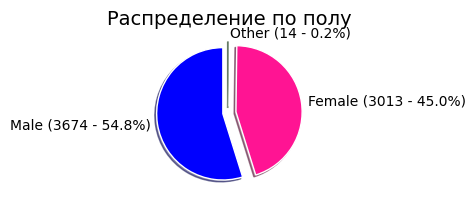

In [ ]:
# Считаем количество мужчин и женщин.
gender_counts = df['Gender'].value_counts()

# Строим круговой график.
plt.figure(figsize=(2, 2))

# Создаем метки с процентами и количеством.
labels = [f'{label} ({count} - {percentage:.1f}%)'
          for label, count, percentage in zip(gender_counts.index, gender_counts.values, gender_counts.values / gender_counts.sum() * 100)]

# Проверяем количество сегментов для explode. У нас 3 сегмента: Male, Female, Other.
explode_list = [0.1] * len(gender_counts) # Создаем список explode соответствующей длины.

plt.pie(gender_counts, labels=labels, autopct='', startangle=90, colors=['blue', 'deeppink', 'green'],
        wedgeprops={'edgecolor': 'white'}, explode=explode_list, shadow=True) # Добавляем shadow=True для имитации объема и исправляем explode.
plt.title('Распределение по полу', fontsize=14)
plt.axis('equal')  # Убедимся, что график круглый.
plt.show()

В колонке "Gender" содержится 14 значений "Other" (другое). Заменим их на "Male и "Female" и распределим между мужчинами и женщинами в соответствии с общими показателями - 55% мужской пол и 45% женский.

Распределение Gender после замены 'Other':
Gender
Male      3681
Female    3020
Name: count, dtype: int64

Количество значений 'Other' после замены: 0


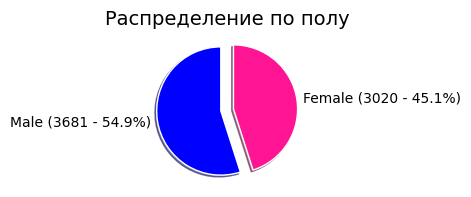

In [ ]:
# Выбираем строки со значением 'Other' в столбце 'Gender'.
other = df[df['Gender'] == 'Other'].index

# Определяем количество значений для каждого пола на основе процентного соотношения.
total_other = len(other)
num_male = int(total_other * 0.55)
num_female = total_other - num_male

# Создаем список значений для замены с учетом распределения.
replacement_values = ['Male'] * num_male + ['Female'] * num_female

# Перемешиваем список значений для случайного распределения.
import random
random.shuffle(replacement_values)

# Заменяем значения в исходном DataFrame.
df.loc[other, 'Gender'] = replacement_values

# Проверяем распределение значений после замены.
print("Распределение Gender после замены 'Other':")
print(df['Gender'].value_counts())

# Проверяем, что значение 'Other' больше не присутствует.
print("\nКоличество значений 'Other' после замены:", (df['Gender'] == 'Other').sum())

# Считаем количество мужчин и женщин.
gender_counts = df['Gender'].value_counts()

# Строим круговой график.
plt.figure(figsize=(2, 2))

# Создаем метки с процентами и количеством.
labels = [f'{label} ({count} - {percentage:.1f}%)'
          for label, count, percentage in zip(gender_counts.index, gender_counts.values, gender_counts.values / gender_counts.sum() * 100)]

# Проверяем количество сегментов для explode. Теперь у нас 2 сегмента: Male, Female.
explode_list = [0.1] * len(gender_counts) # Создаем список explode соответствующей длины.

plt.pie(gender_counts, labels=labels, autopct='', startangle=90, colors=['blue', 'deeppink'],
        wedgeprops={'edgecolor': 'white'}, explode=explode_list, shadow=True) # Добавляем shadow=True для имитации объема и исправляем explode.
plt.title('Распределение по полу', fontsize=14)
plt.axis('equal')  # Убедимся, что график круглый.
plt.show()

Построим графики Box Plot, чтобы посмотреть в каких диапазонах содержится основной объем данных и проверить выбросы.

Описательная статистика:
               Age  Years of Experience         Salary
count  6701.000000          6701.000000    6701.000000
mean     33.621997             8.094687  115323.595915
std       7.614632             6.059003   52781.049697
min      21.000000             0.000000     350.000000
25%      28.000000             3.000000   70000.000000
50%      32.000000             7.000000  115000.000000
75%      38.000000            12.000000  160000.000000
max      62.000000            34.000000  250000.000000


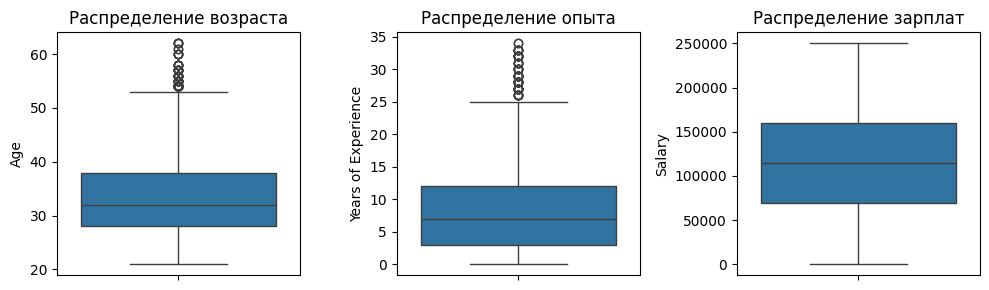

In [ ]:
# Проверим на выбросы.
print("Описательная статистика:")
print(df[['Age', 'Years of Experience', 'Salary']].describe())

# Визуализируем выбросы.
plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Age'])
plt.title('Распределение возраста')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Years of Experience'])
plt.title('Распределение опыта')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Salary'])
plt.title('Распределение зарплат')

plt.tight_layout()
plt.show()

Основная масса работников по возрасту находится в диапазоне 28 - 38 лет, старше 52 лет попадают в аномальные значения, при этом минимальный возраст работников 21 год, максимальный 62 года.
Большинство работников имеют опыт от 3 до 12 лет, работники с опытом выше 25 лет попадают в аномалии, при этом минимальный стаж начинается с 0 лет, максимальный составляет 34 года.
Зарплаты в основном диапазоне 70_000.0 - 160_000.0, есть выбросы по минимальной зарплате, при этом минимальная зарплата начинается с 350.0, максимальная достигает 250_000.0.

Стандартизируем выбросы по минимальной зарплате. Очевидно, что это опечатка и в них пропустили два нуля, когда заполняли показатели.

In [ ]:
# Посмотрим на самые низкие зарплаты.
print("Самые низкие зарплаты:")
low_salaries = df[df['Salary'] < 10000].sort_values('Salary')
display(low_salaries[['EmployeeID', 'Job Title', 'Years of Experience', 'Salary']].head(20))

# Проверим, есть ли закономерность - возможно, все зарплаты ниже определенного порога нужно умножить на 100.
low_salary_threshold = 10000  # например, все зарплаты ниже 10,000 - это ошибка.
salaries_to_fix = df['Salary'] < low_salary_threshold

print(f"Количество зарплат ниже {low_salary_threshold}: {salaries_to_fix.sum()}")

Самые низкие зарплаты:


,EmployeeID,Job Title,Years of Experience,Salary
259,1260,Junior Business Operations Analyst,1.5,350.0
4633,5634,Junior Hr Coordinator,4.0,500.0
1890,2891,Front End Developer,1.0,550.0
2654,3655,Software Engineer Manager,1.0,579.0


Количество зарплат ниже 10000: 4


Учитывая, что при минимальном возрасте (21 год) и минимальном опыте (0 лет) минимальные зарплаты начинаются от 25_000.0, то это точно ошибка и эти 4 значения надо умножить на 100.

In [ ]:
def conservative_salary_fix(row):
    salary = row['Salary']

    if salary < 1000:
        return salary * 100

    return salary

df['Salary'] = df.apply(conservative_salary_fix, axis=1)

Проверяем результат.

In [ ]:
print("Статистика зарплат после исправления:")
print(df['Salary'].describe())

Статистика зарплат после исправления:
count      6701.000000
mean     115352.833492
std       52731.408595
min       25000.000000
25%       70000.000000
50%      115000.000000
75%      160000.000000
max      250000.000000
Name: Salary, dtype: float64


Рассмотрим влияние образования на зарплату.

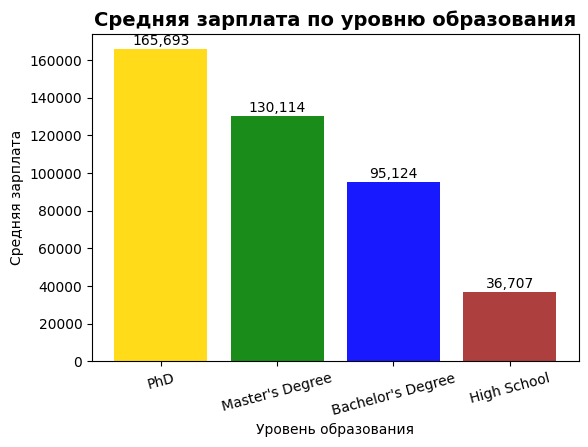

In [ ]:
plt.figure(figsize=(11, 8))

# Средняя зарплата по уровню образования.
plt.subplot(2, 2, 1)
education_salary = df.groupby('Education Level')['Salary'].mean().sort_values(ascending=False)
colors = ['gold', 'green', 'blue', 'brown']
bars = plt.bar(education_salary.index, education_salary.values, color=colors, alpha=0.9)
plt.title('Средняя зарплата по уровню образования', fontsize=14, fontweight='bold')
plt.xlabel('Уровень образования')
plt.ylabel('Средняя зарплата')
plt.xticks(rotation=15)

# Добавляем значения на столбцы.
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1000,
             f'{height:,.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

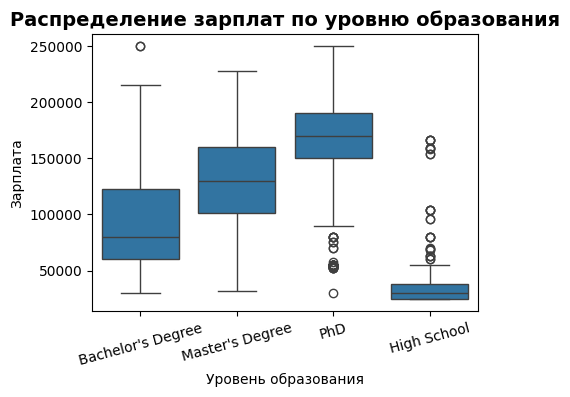

In [ ]:
# Boxplot распределения зарплат по образованию.
plt.figure(figsize=(9, 7))

plt.subplot(2, 2, 2)
sns.boxplot(x='Education Level', y='Salary', data=df)
plt.title('Распределение зарплат по уровню образования', fontsize=14, fontweight='bold')
plt.xlabel('Уровень образования')
plt.ylabel('Зарплата')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

Уровень образования очень существенно влияет на уровень заработной платы. Люди имеющие звание:

*   кандидат наук - в среднем получают больше > магистров на ~21%, бакалавров на ~42%, выпускников старшей школы на ~78%;
*   магистр - в среднем получают больше > бакалавров на ~27%, выпускников старшей школы на ~72%;
*   бакалавр - в среднем получают больше > выпускников старшей школы на ~62%.

Из графика распределения видно, что основной максимум зарплаты бакалавров находится приблизительно на уровне медианы магистров, а основной максимум зарплаты магистров находится приблизительно на уровне первой квартили кандидатов наук. Работники, у которых уровень образования старшая школа, получают зарплату на уровне минимальных зарплат бакалавров и магистров.

При этом по распределению зарплат видно, что большая часть людей выбирает уровень бакалавра, немного меньше заинтересованы в окончании магистратуры, количество имеющих степень кандидата наук примерно в два раза меньше, чем бакалавров или магистров. Количество человек, не продолживших свое обучение после школы намного меньше любого из трех рассмотренных уровней.





Влияние опыта работы на зарплату.

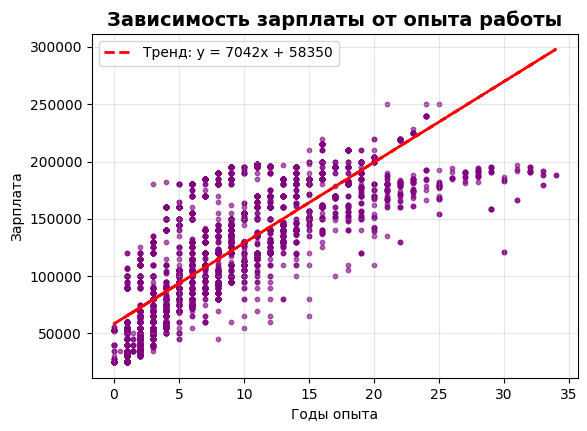

In [ ]:
plt.figure(figsize=(11, 8))

plt.subplot(2, 2, 3)
plt.scatter(df['Years of Experience'], df['Salary'], alpha=0.6, color='purple', s=10)
plt.title('Зависимость зарплаты от опыта работы', fontsize=14, fontweight='bold')
plt.xlabel('Годы опыта')
plt.ylabel('Зарплата')
plt.grid(True, alpha=0.3)

# Линия тренда
z = np.polyfit(df['Years of Experience'], df['Salary'], 1)
p = np.poly1d(z)
plt.plot(df['Years of Experience'], p(df['Years of Experience']), "r--", linewidth=2,
         label=f'Тренд: y = {z[0]:.0f}x + {z[1]:.0f}')
plt.legend()

plt.tight_layout()
plt.show()

Наблюдается сильная линейная зависимость зарплаты от опыта, каждый год стажа приносит 7_000.0 к зарплате. Некоторое отклонение от линии тренда в большинстве случаях обусловлено разным уровнем образования. Однако после 20 лет стажа мы видим в основной массе горизонтальное распределение кластеров, следовательно, к этому времени зарплата достигает своего максимума и опыт уже не влияет на рост заработной платы.

Влияние возраста на зарплату.

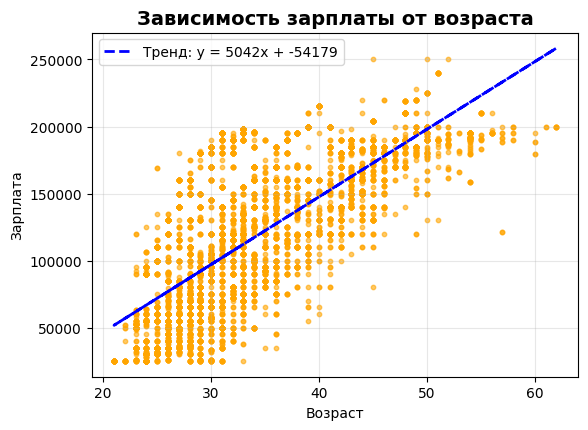

In [ ]:
plt.figure(figsize=(11, 8))

plt.subplot(2, 2, 4)
plt.scatter(df['Age'], df['Salary'], alpha=0.6, color='orange', s=10)
plt.title('Зависимость зарплаты от возраста', fontsize=14, fontweight='bold')
plt.xlabel('Возраст')
plt.ylabel('Зарплата')
plt.grid(True, alpha=0.3)

# Линия тренда
z_age = np.polyfit(df['Age'], df['Salary'], 1)
p_age = np.poly1d(z_age)
plt.plot(df['Age'], p_age(df['Age']), "b--", linewidth=2,
         label=f'Тренд: y = {z_age[0]:.0f}x + {z_age[1]:.0f}')
plt.legend()

plt.tight_layout()
plt.show()

Линейная зависимость зарплаты от возраста тоже сильна, хоть она несколько меньше зависимости от опыта и есть некоторые случаи горизонтального распределения в возрасте 21 - 31 год и после 50-ти лет, в основном же тренд составляет увеличение зарплаты на 5_000.0 с каждым годом.

Посмотрим на разницу в зарплате между мужчинами и женщинами.

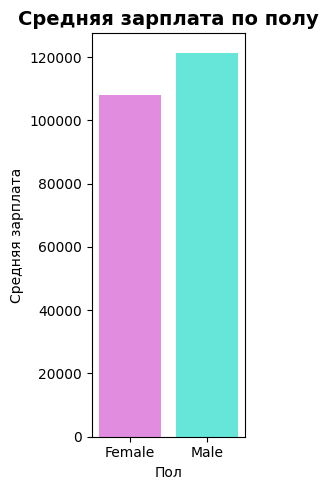

In [ ]:
plt.figure(figsize=(6, 5))

# Средняя зарплата по полу.
plt.subplot(1, 3, 1)
gender_salary = df.groupby('Gender')['Salary'].mean()
colors_gender = ['orchid', 'turquoise']
bars_gender = plt.bar(gender_salary.index, gender_salary.values, color=colors_gender, alpha=0.8)
plt.title('Средняя зарплата по полу', fontsize=14, fontweight='bold')
plt.xlabel('Пол')
plt.ylabel('Средняя зарплата')

plt.tight_layout()
plt.show()

В среднем мужчины получают больше женщин на 11%.

Линейный график роста зарплат по опыту работы для мужчин и женщин.

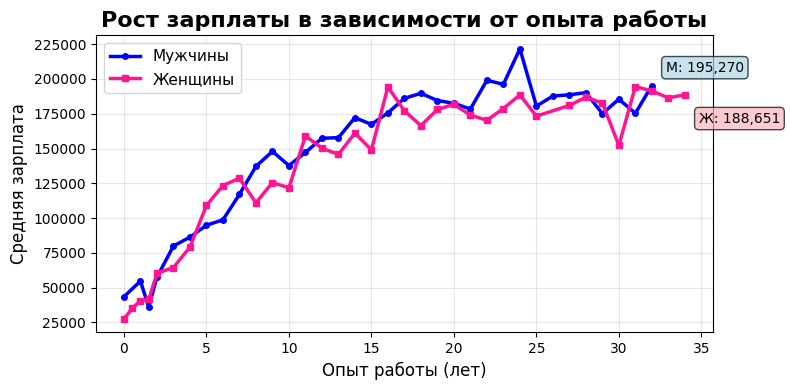

In [ ]:
plt.figure(figsize=(8, 4))

# Группируем по опыту работы и полу, вычисляем среднюю зарплату.
experience_gender_salary = df.groupby(['Years of Experience', 'Gender'])['Salary'].mean().reset_index()

# Разделяем данные для мужчин и женщин.
male_data = experience_gender_salary[experience_gender_salary['Gender'] == 'Male']
female_data = experience_gender_salary[experience_gender_salary['Gender'] == 'Female']

# Строим линейные графики.
plt.plot(male_data['Years of Experience'], male_data['Salary'],
         label='Мужчины', color='blue', linewidth=2.5, marker='o', markersize=4)
plt.plot(female_data['Years of Experience'], female_data['Salary'],
         label='Женщины', color='deeppink', linewidth=2.5, marker='s', markersize=4)

plt.title('Рост зарплаты в зависимости от опыта работы', fontsize=16, fontweight='bold')
plt.xlabel('Опыт работы (лет)', fontsize=12)
plt.ylabel('Средняя зарплата', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Добавляем аннотации для ключевых точек.
max_male_exp = male_data['Years of Experience'].max()
max_female_exp = female_data['Years of Experience'].max()

plt.annotate(f'М: {male_data["Salary"].iloc[-1]:,.0f}',
             xy=(max_male_exp, male_data["Salary"].iloc[-1]),
             xytext=(10, 10), textcoords='offset points',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.7))

plt.annotate(f'Ж: {female_data["Salary"].iloc[-1]:,.0f}',
             xy=(max_female_exp, female_data["Salary"].iloc[-1]),
             xytext=(10, -20), textcoords='offset points',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightpink', alpha=0.7))

plt.tight_layout()
plt.show()

На графике видно, что на старте мужчинам предлагается более высокая зарплата. Есть всплески, кода зарплата женщин выше зарплаты мужчин, но в общей картине зарплата мужчин превышает зарплату женщин. Возможно стоит изучить ситуацию и выяснить, почему после роста зарплаты у женщин происходит ее падение.

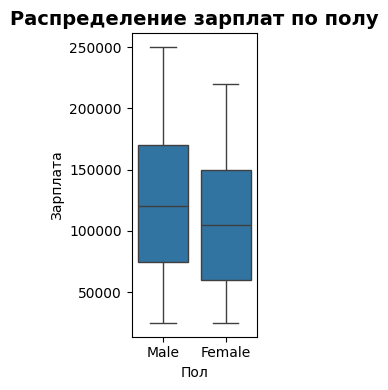

In [ ]:
# Boxplot зарплат по полу.
plt.figure(figsize=(6, 4))

plt.subplot(1, 3, 2)
sns.boxplot(x='Gender', y='Salary', data=df)
plt.title('Распределение зарплат по полу', fontsize=14, fontweight='bold')
plt.xlabel('Пол')
plt.ylabel('Зарплата')

plt.tight_layout()
plt.show()

Наблюдается, что основная масса работников мужчин имеет минимальную зарплату в пределах 75_000.0, а максимальную в пределах 170_000.0. У женщин основная масса работников имеет минимальную зарплату в пределах 65_000.0, а максимальную в пределах 150_000.0. Средняя разница в зарплате составляет 15_000.0.

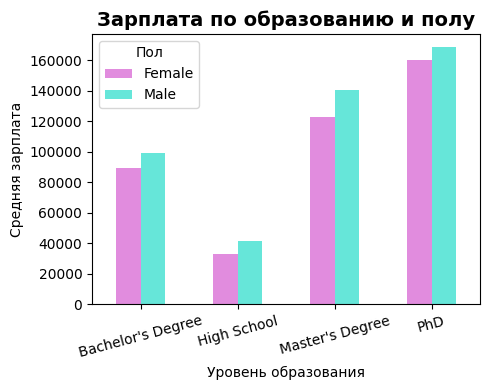

In [ ]:
# Гендерный разрыв по уровню образования.
gender_education_salary = df.groupby(['Education Level', 'Gender'])['Salary'].mean().unstack()
gender_education_salary.plot(kind='bar', figsize=(5, 4), color=colors_gender, alpha=0.8)
plt.title('Зарплата по образованию и полу', fontsize=14, fontweight='bold')
plt.xlabel('Уровень образования')
plt.ylabel('Средняя зарплата')
plt.xticks(rotation=15)
plt.legend(title='Пол')

plt.tight_layout()
plt.show()

Видно, что разница зарплаты между работниками мужского и женского пола сохраняется по всем уровням образования в пользу работников мужского пола, при этом в трех областях разница в районе 10_000.0, а в области магистратуры в районе 20_000.0.

Статистический анализ гендерного разрыва.

In [ ]:
from scipy import stats

print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ГЕНДЕРНОГО РАЗРЫВА")
print("~" * 40)

# Средние зарплаты.
male_salaries = df[df['Gender'] == 'Male']['Salary']
female_salaries = df[df['Gender'] == 'Female']['Salary']

print(f"Средняя зарплата мужчин: {male_salaries.mean():,.2f}")
print(f"Средняя зарплата женщин: {female_salaries.mean():,.2f}")
print(f"Разница: {male_salaries.mean() - female_salaries.mean():,.2f}")
print(f"Относительный разрыв: {(male_salaries.mean() - female_salaries.mean()) / male_salaries.mean() * 100:.1f}%")

СТАТИСТИЧЕСКИЙ АНАЛИЗ ГЕНДЕРНОГО РАЗРЫВА
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Средняя зарплата мужчин: 121,431.35
Средняя зарплата женщин: 107,943.89
Разница: 13,487.46
Относительный разрыв: 11.1%


Статистический анализ показал: средняя зарплата мужчин: 121_378.21, средняя зарплата женщин: 108_008.66, разница: 13_369.55, относительный разрыв з/п: 11.0%.

In [ ]:
# T-тест для проверки статистической значимости.
t_stat, p_value = stats.ttest_ind(male_salaries, female_salaries)
print(f"\nT-тест: t-статистика = {t_stat:.2f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("✅ Разница статистически значима (p < 0.05)")
else:
    print("❌ Разница не статистически значима")


T-тест: t-статистика = 10.50, p-value = 0.0000
✅ Разница статистически значима (p < 0.05)


Т-тест Стьюдента показал положительную статистику и выявил, что абсолютное значение очень высокое, величина эффекта огромна, разница между группами более чем в 10 раз превышает разницу, возникающую внутри групп.

Статистическая значимость экстремально высокая, результат p-value равен 0,0000, поэтому гендерный разрыв зарплаты не может быть объяснен случайными факторами.

In [ ]:
# Анализ по должностям.
print("ГЕНДЕРНЫЙ РАЗРЫВ ПО ДОЛЖНОСТЯМ (топ-10):")
top_jobs = df['Job Title'].value_counts().head(10).index

for job in top_jobs:
    job_data = df[df['Job Title'] == job]
    if len(job_data['Gender'].unique()) > 1:
        male_avg = job_data[job_data['Gender'] == 'Male']['Salary'].mean()
        female_avg = job_data[job_data['Gender'] == 'Female']['Salary'].mean()
        if not (pd.isna(male_avg) or pd.isna(female_avg)):
            gap = male_avg - female_avg
            gap_percent = (gap / male_avg * 100) if male_avg > 0 else 0
            print(f"{job}: Мужчины {male_avg:,.0f} vs Женщины {female_avg:,.0f} | Разрыв: {gap:,.0f} ({gap_percent:.1f}%)")

ГЕНДЕРНЫЙ РАЗРЫВ ПО ДОЛЖНОСТЯМ (топ-10):
Software Engineer: Мужчины 118,335 vs Женщины 104,668 | Разрыв: 13,667 (11.5%)
Data Scientist: Мужчины 168,442 vs Женщины 163,203 | Разрыв: 5,239 (3.1%)
Software Engineer Manager: Мужчины 172,967 vs Женщины 171,793 | Разрыв: 1,174 (0.7%)
Data Analyst: Мужчины 130,675 vs Женщины 114,961 | Разрыв: 15,714 (12.0%)
Senior Project Engineer: Мужчины 173,548 vs Женщины 150,939 | Разрыв: 22,609 (13.0%)
Product Manager: Мужчины 127,297 vs Женщины 172,981 | Разрыв: -45,684 (-35.9%)
Full Stack Engineer: Мужчины 131,637 vs Женщины 122,411 | Разрыв: 9,226 (7.0%)
Front End Developer: Мужчины 86,914 vs Женщины 79,698 | Разрыв: 7,216 (8.3%)
Marketing Manager: Мужчины 127,203 vs Женщины 113,061 | Разрыв: 14,142 (11.1%)
Back End Developer: Мужчины 106,155 vs Женщины 92,307 | Разрыв: 13,849 (13.0%)


Анализ по должностям показал разрыв между зарплатами мужчин и женщин от 0,7% до 13,0%. Однако по должности Product Manager выявлен очень высокий отрицательный разрыв -35,9% (45_684.0), т.е. на этой должности мы наблюдаем обратную направленность, причем количественно превосходящую в несколько раз показатели по любой другой должности.

Product Manager - проверим аномалию.

Всего Product Managers: 313
Мужчины: 209
Женщины: 104


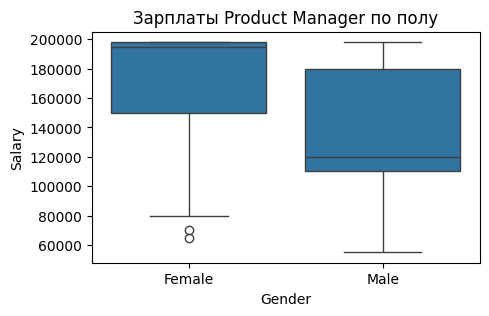


Опыт работы Product Managers:
        count      mean       std  min  25%   50%   75%   max
Gender                                                       
Female  104.0  9.105769  3.237877  2.0  7.0  11.0  11.0  12.0
Male    209.0  7.138756  4.428370  1.0  3.0   7.0  11.0  14.0

Образование Product Managers:
Gender  Education Level  
Female  Master's Degree       74
        Bachelor's Degree     30
Male    Bachelor's Degree    126
        Master's Degree       78
        PhD                    5
Name: count, dtype: int64


In [ ]:
# Детально изучим Product Manager.
pm_data = df[df['Job Title'] == 'Product Manager']
print(f"Всего Product Managers: {len(pm_data)}")
print(f"Мужчины: {len(pm_data[pm_data['Gender'] == 'Male'])}")
print(f"Женщины: {len(pm_data[pm_data['Gender'] == 'Female'])}")

# Посмотрим на распределение.
plt.figure(figsize=(5, 3))
sns.boxplot(x='Gender', y='Salary', data=pm_data)
plt.title('Зарплаты Product Manager по полу')
plt.show()

# Проверим опыт и образование.
print("\nОпыт работы Product Managers:")
print(pm_data.groupby('Gender')['Years of Experience'].describe())
print("\nОбразование Product Managers:")
print(pm_data.groupby('Gender')['Education Level'].value_counts())

График Boxplot показал, что основной диапазон зарплат у женщин на должности Product Manager находится от 150_000.0 до 198_000.0. Аномалий, которые могли бы сдвинуть показатели в сторону повышения, нет, значит данные корректны.
Средний стаж у женщин (9 лет) выше, чем у мужчин (7 лет) и более сконцентрирован к центру (9+-3 против 7+-4,5). Две трети женщин (74) имеют уровень образования магистратуры против бакалавриата (30) и примерно равно количеству мужчин с уровнем магистров (78) при учете, что Product Manager у женщин пользуется в два раза меньшей популярностью, чем у мужчин (104 и 209 соответственно).

Учет взаимодействия факторов - множественная регрессия.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

# Подготовка данных для регрессии.
df_encoded = df.copy()
le = LabelEncoder()
df_encoded['Gender_encoded'] = le.fit_transform(df_encoded['Gender'])  # Male=1, Female=0
df_encoded['Education_encoded'] = le.fit_transform(df_encoded['Education Level'])

# Множественная регрессия.
X = df_encoded[['Education_encoded', 'Years of Experience', 'Age', 'Gender_encoded']]
y = df_encoded['Salary']

model = LinearRegression()
model.fit(X, y)

# Предсказания для визуализации.
df_encoded['Predicted_Salary'] = model.predict(X)

print("КОЭФФИЦИЕНТЫ ВЛИЯНИЯ ФАКТОРОВ НА ЗАРПЛАТУ:")
print("~" * 40)
print(f"Образование: {model.coef_[0]:.0f}")
print(f"Опыт работы: {model.coef_[1]:.0f}")
print(f"Возраст: {model.coef_[2]:.0f}")
print(f"Пол: {model.coef_[3]:.0f}")
print(f"R² (качество модели): {model.score(X, y):.3f}")

# Интерпретация коэффициентов.
education_levels = dict(zip(le.classes_, range(len(le.classes_))))
print(f"\nКодировка образования: {education_levels}")
print("Пол: 0 = Female, 1 = Male")

КОЭФФИЦИЕНТЫ ВЛИЯНИЯ ФАКТОРОВ НА ЗАРПЛАТУ:
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Образование: 6218
Опыт работы: 8789
Возраст: -2110
Пол: 7325
R² (качество модели): 0.680

Кодировка образования: {"Bachelor's Degree": 0, 'High School': 1, "Master's Degree": 2, 'PhD': 3}
Пол: 0 = Female, 1 = Male


Визуализация взаимодействия факторов.

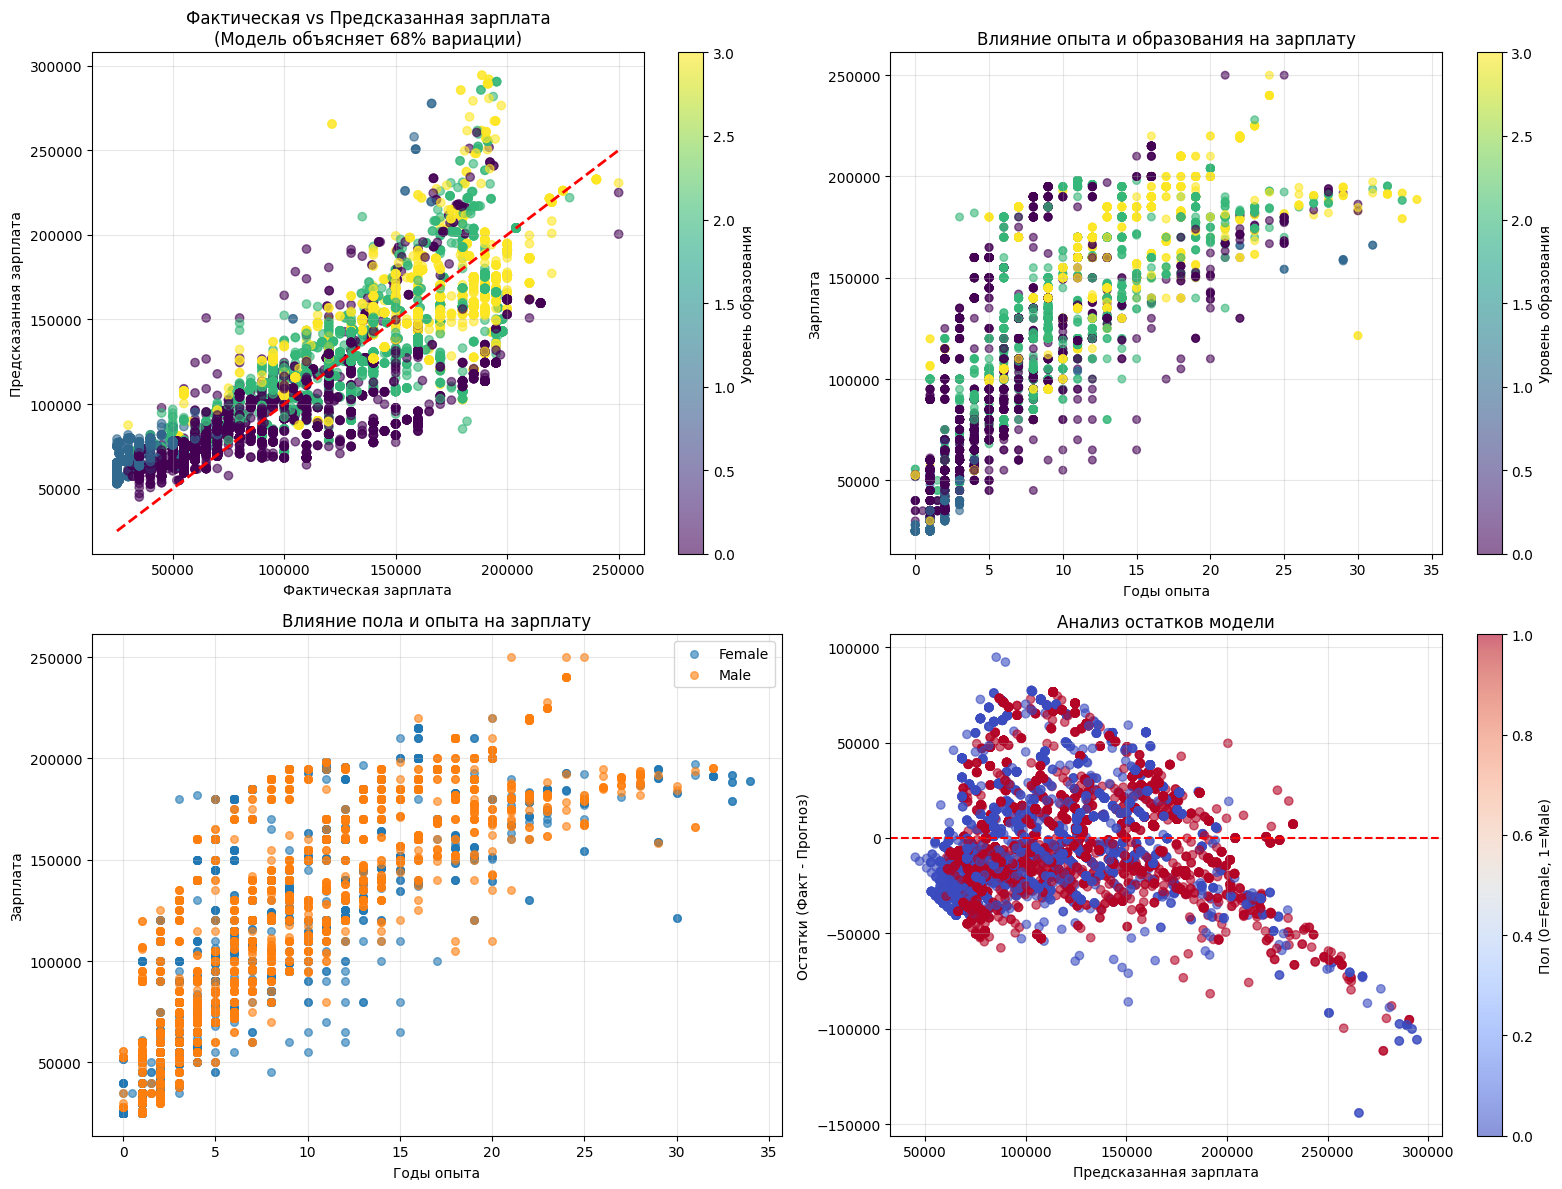

In [ ]:
plt.figure(figsize=(16, 12))

# Фактическая vs Предсказанная зарплата.
plt.subplot(2, 2, 1)
plt.scatter(df_encoded['Salary'], df_encoded['Predicted_Salary'], alpha=0.6, c=df_encoded['Education_encoded'], cmap='viridis')
plt.plot([df_encoded['Salary'].min(), df_encoded['Salary'].max()],
         [df_encoded['Salary'].min(), df_encoded['Salary'].max()], 'r--', linewidth=2)
plt.colorbar(label='Уровень образования')
plt.xlabel('Фактическая зарплата')
plt.ylabel('Предсказанная зарплата')
plt.title('Фактическая vs Предсказанная зарплата\n(Модель объясняет 68% вариации)')
plt.grid(True, alpha=0.3)

# Влияние опыта и образования на зарплату.
plt.subplot(2, 2, 2)
scatter = plt.scatter(df_encoded['Years of Experience'], df_encoded['Salary'],
                     c=df_encoded['Education_encoded'], alpha=0.6, cmap='viridis', s=30)
plt.colorbar(scatter, label='Уровень образования')
plt.xlabel('Годы опыта')
plt.ylabel('Зарплата')
plt.title('Влияние опыта и образования на зарплату')
plt.grid(True, alpha=0.3)

# Взаимодействие пола и опыта.
plt.subplot(2, 2, 3)
for gender in [0, 1]:
    gender_data = df_encoded[df_encoded['Gender_encoded'] == gender]
    plt.scatter(gender_data['Years of Experience'], gender_data['Salary'],
               alpha=0.6, s=30, label=f"{'Male' if gender == 1 else 'Female'}")

plt.xlabel('Годы опыта')
plt.ylabel('Зарплата')
plt.title('Влияние пола и опыта на зарплату')
plt.legend()
plt.grid(True, alpha=0.3)

# Остатки модели.
plt.subplot(2, 2, 4)
residuals = df_encoded['Salary'] - df_encoded['Predicted_Salary']
plt.scatter(df_encoded['Predicted_Salary'], residuals, alpha=0.6, c=df_encoded['Gender_encoded'], cmap='coolwarm')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанная зарплата')
plt.ylabel('Остатки (Факт - Прогноз)')
plt.title('Анализ остатков модели')
plt.colorbar(label='Пол (0=Female, 1=Male)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Образование: Bachelor's Degree = 0, High School = 1, Master's Degree = 2, PhD = 3

Пол: 0 = Female, 1 = Male

Через множественную регрессию получаем коэффициенты влияния факторов на зарплату:

*   каждый уровень образования дает к зарплате 6_217.0;
*   каждый год стажа дает к зарплате 8_792.0;
*   каждый год возраста снижает зарплату на 2_112.0;
*   мужчины получают на 7_374.0 больше женщин;

R² = 0.680 - модель объясняет 68% вариации зарплат.

Опыт главный фактор, он ценится больше образования. Возраст имеет отрицательный эффект - при равном опыте и образовании молодые получают больше, возможно эту проблему социального неравенства надо изучать. Гендерный разрыв подтвержден: 7_374.0 в пользу мужчин.



Дополнительная визуализация о совместном влиянии опыта, образования и пола на зарплату.

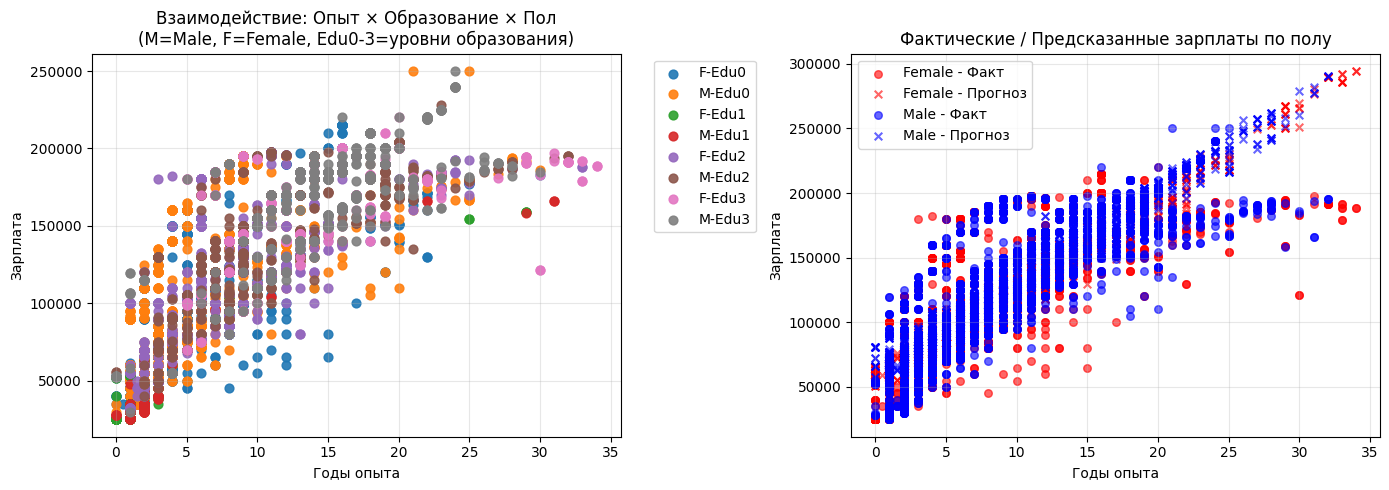

In [ ]:
plt.figure(figsize=(14, 5))

# Образование + Опыт + Пол.
plt.subplot(1, 2, 1)
for education_level in sorted(df_encoded['Education_encoded'].unique()):
    for gender in [0, 1]:
        mask = (df_encoded['Education_encoded'] == education_level) & (df_encoded['Gender_encoded'] == gender)
        subset = df_encoded[mask]
        if len(subset) > 0:
            plt.scatter(subset['Years of Experience'], subset['Salary'],
                       alpha=0.9, s=40,
                       label=f"{'M' if gender == 1 else 'F'}-Edu{education_level}")

plt.xlabel('Годы опыта')
plt.ylabel('Зарплата')
plt.title('Взаимодействие: Опыт × Образование × Пол\n(M=Male, F=Female, Edu0-3=уровни образования)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

# Сравнение фактических и предсказанных значений по полу.
plt.subplot(1, 2, 2)
gender_labels = {0: 'Female', 1: 'Male'}
colors = ['red', 'blue']

for gender in [0, 1]:
    gender_data = df_encoded[df_encoded['Gender_encoded'] == gender]
    plt.scatter(gender_data['Years of Experience'], gender_data['Salary'],
               alpha=0.6, s=30, color=colors[gender], label=f"{gender_labels[gender]} - Факт")
    plt.scatter(gender_data['Years of Experience'], gender_data['Predicted_Salary'],
               alpha=0.6, s=30, color=colors[gender], marker='x',
               label=f"{gender_labels[gender]} - Прогноз")

plt.xlabel('Годы опыта')
plt.ylabel('Зарплата')
plt.title('Фактические / Предсказанные зарплаты по полу')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1.   Слои по образованию: Как и на предыдущих графиках, видно, что точки с      более высоким уровнем образования расположены выше по оси зарплаты при одинаковом стаже.
2.   Разделение по полу: Внутри каждого "слоя" образования можно увидеть разделение по полу (M для мужчин, F для женщин). Синие точки (мужчины) часто находятся немного выше красных точек (женщины) в пределах одной группы образования и стажа.
3.   Тренды по стажу: Для каждой комбинации образования и пола виден свой тренд роста зарплаты с увеличением стажа.


Эта визуализация позволяет увидеть более тонкие зависимости и подтвердить выводы о совместном влиянии опыта, образования и пола на зарплату. Она помогает визуально оценить, насколько сильны эти взаимодействия в разных сегментах данных.

Можно предположить, что мужчины и женщины имеют гендерное различие в способностях решать разные задачи. В следствии этого было бы целесообразным проводить рекомендательные беседы по выбору направления обучения среди мужчин и женщин, определяющихся с выбором профессии.

Кроме должности Product Manager женщинам можно предлагать связать свою деятельность с Software Engineer Manager (разрыв 0,7%) и Data Scientist (разрыв 3,1%). Разница в этих должностях не большая и женщины могут составить в них хорошую конкуренцию мужчинам. В крайнем случае можно рекомендовать Full Stack Engineer (разница 6,1%). Предполагаю, что правильное распределение мужчин и женщин в сферах деятельности приведет к выравниванию по уровням зарплат, а также к повышению доходов компаний за счет улучшения качества работ.

Завершение EDA и переход к Machine Learning.

Машинное обучение.

Задача: "Предсказание (прогноз) уровня заработной платы по полу, должности и уровню образования".

In [ ]:
# =====================
# 1. ПОДГОТОВКА ДАННЫХ
# =====================

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Кодируем категориальные признаки.
df_ml = df.copy()

# Метод 1: Label Encoding для линейных моделей.
le_job = LabelEncoder()
le_education = LabelEncoder()
le_gender = LabelEncoder()

df_ml['Job_encoded'] = le_job.fit_transform(df_ml['Job Title'])
df_ml['Education_encoded'] = le_education.fit_transform(df_ml['Education Level'])
df_ml['Gender_encoded'] = le_gender.fit_transform(df_ml['Gender'])

# Метод 2: One-Hot Encoding для tree-based моделей.
df_ml = pd.get_dummies(df_ml, columns=['Job Title', 'Education Level', 'Gender'], prefix=['Job', 'Edu', 'Gender'])

print("Размерность данных после кодирования:", df_ml.shape)

Размерность данных после кодирования: (6701, 204)


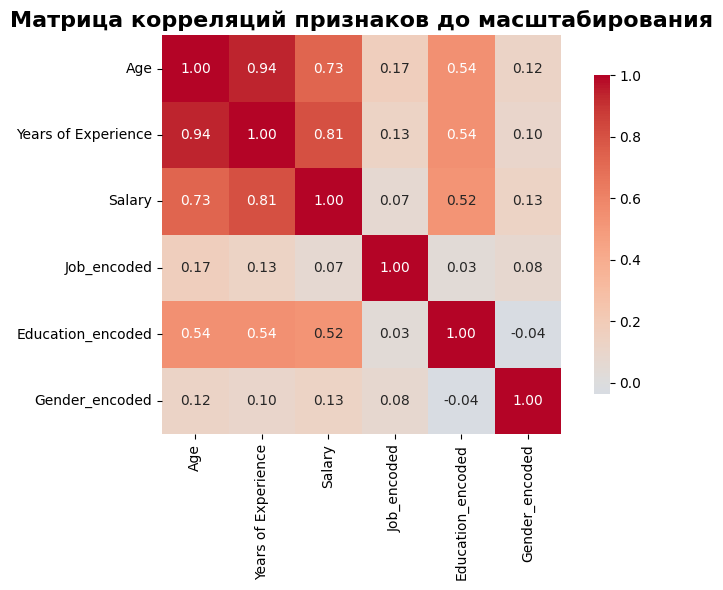

Наиболее коррелирующие с Salary признаки:
Years of Experience    0.809148
Age                    0.728127
Education_encoded      0.524936
Gender_encoded         0.127274
Job_encoded            0.065147
Name: Salary, dtype: float64


In [ ]:
# ===========================
# 2. МАТРИЦА КОРРЕЛЯЦИЙ HEATMAP (ПИРСОНА)
# ===========================

# Выберем основные числовые и закодированные признаки для визуализации.
corr_columns = ['Age', 'Years of Experience', 'Salary', 'Job_encoded', 'Education_encoded', 'Gender_encoded']
correlation_matrix = df_ml[corr_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций признаков до масштабирования', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Наиболее коррелирующие с Salary признаки:")
salary_corr = correlation_matrix['Salary'].sort_values(ascending=False)
print(salary_corr[1:])  # исключаем сам Salary.

In [ ]:
# ===========================
# 3. ПОДГОТОВКА ПРИЗНАКОВ И ТАРГЕТА
# ===========================

# Выбираем фичи для разных подходов.
# Для линейных моделей.
features_linear = ['Age', 'Years of Experience', 'Job_encoded', 'Education_encoded', 'Gender_encoded']

# Для tree-based моделей (one-hot encoded).
features_tree = [col for col in df_ml.columns if col.startswith(('Job_', 'Edu_', 'Gender_'))] + ['Age', 'Years of Experience']

X_linear = df_ml[features_linear]
X_tree = df_ml[features_tree]
y = df_ml['Salary']

print(f"Линейные фичи: {X_linear.shape}")
print(f"Tree-based фичи: {X_tree.shape}")

# Масштабирование для линейных моделей.
scaler = StandardScaler()
X_linear_scaled = scaler.fit_transform(X_linear)
X_linear_scaled = pd.DataFrame(X_linear_scaled, columns=features_linear)

# Разделение на train/test для ЛИНЕЙНЫХ моделей.
X_linear_train, X_linear_test, y_linear_train, y_linear_test = train_test_split(
    X_linear_scaled, y, test_size=0.2, random_state=42)

# Разделение на train/test для TREE-BASED моделей.
X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    X_tree, y, test_size=0.2, random_state=42)

print(f"\nЛинейные модели - Train: {X_linear_train.shape}, Test: {X_linear_test.shape}")
print(f"Tree-based модели - Train: {X_tree_train.shape}, Test: {X_tree_test.shape}")

Линейные фичи: (6701, 5)
Tree-based фичи: (6701, 201)

Линейные модели - Train: (5360, 5), Test: (1341, 5)
Tree-based модели - Train: (5360, 201), Test: (1341, 201)


In [ ]:
# ===========================
# 4. СОЗДАНИЕ И ОБУЧЕНИЕ МОДЕЛЕЙ
# ===========================

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

models = {
    # Линейные модели.
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),

    # Tree-based модели.
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),

    # SVM
    'SVR': SVR(kernel='rbf', C=1.0)
}

# Словари для хранения результатов.
results = {}
feature_importances = {}

print("🚀 ОБУЧЕНИЕ МОДЕЛЕЙ...")
print("=" * 50)

# Обучаем все модели и сохраняем результаты.
for name, model in models.items():
    print(f"Обучение: {name}")

    # Выбираем правильные данные для модели.
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'SVR']:
        X_train, X_test, y_train, y_test = X_linear_train, X_linear_test, y_linear_train, y_linear_test
    else:
        X_train, X_test, y_train, y_test = X_tree_train, X_tree_test, y_tree_train, y_tree_test

    # Обучение и предсказание.
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Метрики.
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Кросс-валидация.
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'R2_CV_mean': cv_scores.mean(),
        'R2_CV_std': cv_scores.std()
    }

    # Важность признаков (если доступно).
    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = model.feature_importances_

    print(f"✅ {name}: R² = {r2:.4f}, RMSE = {rmse:.0f}")

# Определяем лучшую модель после обучения.
# Находим название модели с самым высоким R2 на тестовом наборе.
best_model_name = max(results, key=lambda name: results[name]['R2'])

# Получаем саму обученную модель.
best_model = models[best_model_name]

print(f"\n🏆 Лучшая модель (по R²): {best_model_name}")

🚀 ОБУЧЕНИЕ МОДЕЛЕЙ...
Обучение: Linear Regression
✅ Linear Regression: R² = 0.6784, RMSE = 29531
Обучение: Ridge Regression
✅ Ridge Regression: R² = 0.6784, RMSE = 29532
Обучение: Lasso Regression
✅ Lasso Regression: R² = 0.6784, RMSE = 29531
Обучение: Decision Tree
✅ Decision Tree: R² = 0.9659, RMSE = 9617
Обучение: Random Forest
✅ Random Forest: R² = 0.9721, RMSE = 8705
Обучение: Gradient Boosting
✅ Gradient Boosting: R² = 0.9122, RMSE = 15434
Обучение: XGBoost
✅ XGBoost: R² = 0.9683, RMSE = 9274
Обучение: SVR
✅ SVR: R² = 0.0147, RMSE = 51694

🏆 Лучшая модель (по R²): Random Forest


🏆 РЕЙТИНГ МОДЕЛЕЙ ПО КАЧЕСТВУ:


,MAE,RMSE,R2,R2_CV_mean,R2_CV_std
Random Forest,"3,380","8,705",0.9721,0.9751,0.0043
XGBoost,"5,573","9,274",0.9683,0.9692,0.0039
Decision Tree,"3,278","9,617",0.9659,0.9688,0.0044
Gradient Boosting,"11,331","15,434",0.9122,0.9104,0.0024
Linear Regression,"23,283","29,531",0.6784,0.6796,0.0173
Lasso Regression,"23,283","29,531",0.6784,0.6796,0.0173
Ridge Regression,"23,286","29,532",0.6784,0.6796,0.0173
SVR,"44,810","51,694",0.0147,0.0094,0.0042


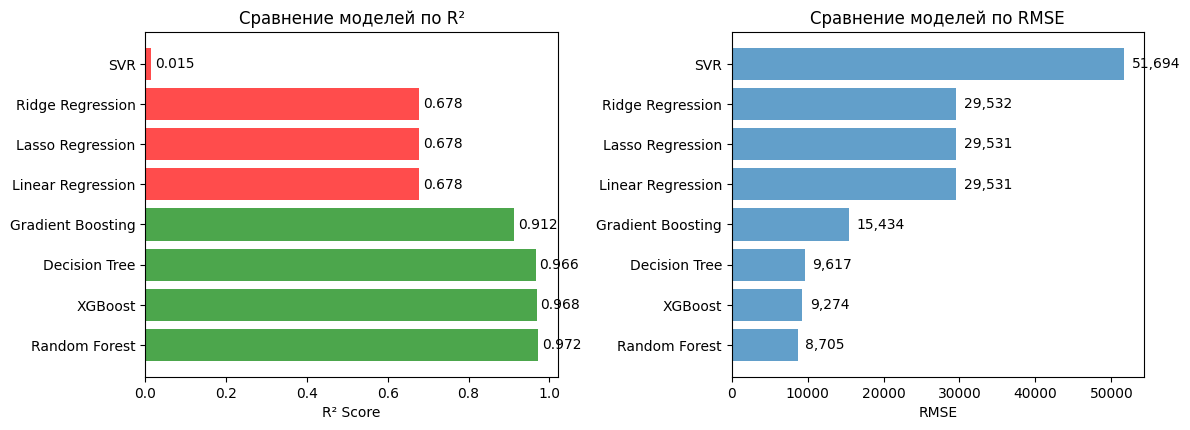

In [ ]:
# ===========================
# 5. СРАВНЕНИЕ РЕЗУЛЬТАТОВ
# ===========================

# Создаем DataFrame с результатами.
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2', ascending=False)

print("🏆 РЕЙТИНГ МОДЕЛЕЙ ПО КАЧЕСТВУ:")
print("=" * 60)
display(results_df.style.format({
    'MAE': '{:,.0f}',
    'RMSE': '{:,.0f}',
    'R2': '{:.4f}',
    'R2_CV_mean': '{:.4f}',
    'R2_CV_std': '{:.4f}'
}).background_gradient(subset=['R2', 'R2_CV_mean'], cmap='viridis'))

# Визуализация сравнения моделей.
plt.figure(figsize=(12, 8))

# График R² scores.
plt.subplot(2, 2, 1)
r2_scores = results_df['R2']
colors = ['green' if x > 0.8 else 'orange' if x > 0.7 else 'red' for x in r2_scores]
bars = plt.barh(range(len(r2_scores)), r2_scores, color=colors, alpha=0.7)
plt.yticks(range(len(r2_scores)), r2_scores.index)
plt.xlabel('R² Score')
plt.title('Сравнение моделей по R²')
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center')

# График RMSE.
plt.subplot(2, 2, 2)
rmse_scores = results_df['RMSE']
plt.barh(range(len(rmse_scores)), rmse_scores, alpha=0.7)
plt.yticks(range(len(rmse_scores)), rmse_scores.index)
plt.xlabel('RMSE')
plt.title('Сравнение моделей по RMSE')
for i, score in enumerate(rmse_scores):
    plt.text(score + 1000, i, f'{score:,.0f}', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# ===========================
# 6. АНАЛИЗ ПЕРЕОБУЧЕНИЯ И ВАЖНОСТИ ПРИЗНАКОВ
# ===========================

print("🔍 АНАЛИЗ ПЕРЕОБУЧЕНИЯ Tree-based МОДЕЛЕЙ:")
print("=" * 50)

# Проверим разницу между R2 на train и test для лучших моделей.
best_models = ['Random Forest', 'XGBoost', 'Decision Tree', 'Gradient Boosting']

for model_name in best_models:
    if model_name in models:
        model = models[model_name]

        # Выбираем правильные данные.
        if model_name in ['Random Forest', 'XGBoost', 'Decision Tree', 'Gradient Boosting']:
            X_train, X_test, y_train, y_test = X_tree_train, X_tree_test, y_tree_train, y_tree_test
        else:
            X_train, X_test, y_train, y_test = X_linear_train, X_linear_test, y_linear_train, y_linear_test

        # Предсказания на train и test.
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # R² на train и test.
        r2_train = r2_score(y_train, y_pred_train)
        r2_test = r2_score(y_test, y_pred_test)
        gap = r2_train - r2_test

        print(f"{model_name}:")
        print(f"  R² Train: {r2_train:.4f}")
        print(f"  R² Test:  {r2_test:.4f}")
        print(f"  Разница:  {gap:.4f} {'🚨 ПЕРЕОБУЧЕНИЕ!' if gap > 0.1 else '✅ НОРМА'}")
        print()

🔍 АНАЛИЗ ПЕРЕОБУЧЕНИЯ Tree-based МОДЕЛЕЙ:
Random Forest:
  R² Train: 0.9923
  R² Test:  0.9721
  Разница:  0.0202 ✅ НОРМА

XGBoost:
  R² Train: 0.9823
  R² Test:  0.9683
  Разница:  0.0140 ✅ НОРМА

Decision Tree:
  R² Train: 0.9946
  R² Test:  0.9659
  Разница:  0.0287 ✅ НОРМА

Gradient Boosting:
  R² Train: 0.9175
  R² Test:  0.9122
  Разница:  0.0054 ✅ НОРМА



🔍 АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ДЛЯ ЛУЧШИХ МОДЕЛЕЙ:

📊 Random Forest - Важность признаков:


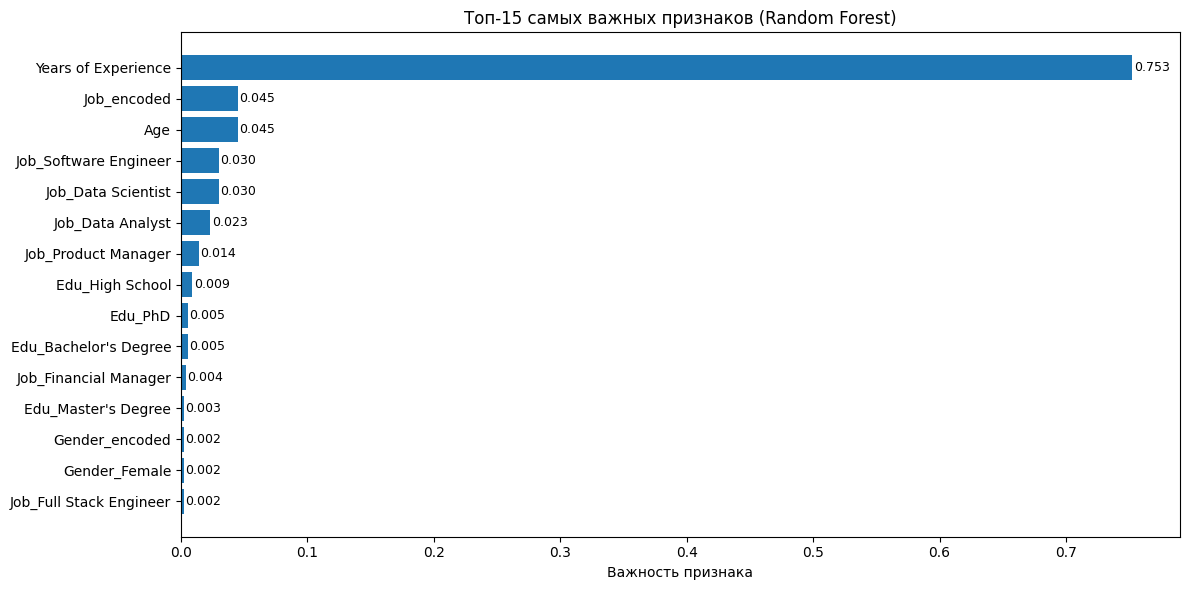

🎯 ТОП-10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ (Random Forest):


,feature,importance
200,Years of Experience,0.7526
0,Job_encoded,0.0449
199,Age,0.0449
177,Job_Software Engineer,0.0303
22,Job_Data Scientist,0.0302
20,Job_Data Analyst,0.0233
108,Job_Product Manager,0.0140
194,Edu_High School,0.0090
196,Edu_PhD,0.0055
193,Edu_Bachelor's Degree,0.0052



📈 АНАЛИЗ ТИПОВ ПРИЗНАКОВ:
   - Должности: 5
   - Образование: 3
   - Пол: 0
   - Числовые: 2

📊 XGBoost - Важность признаков:


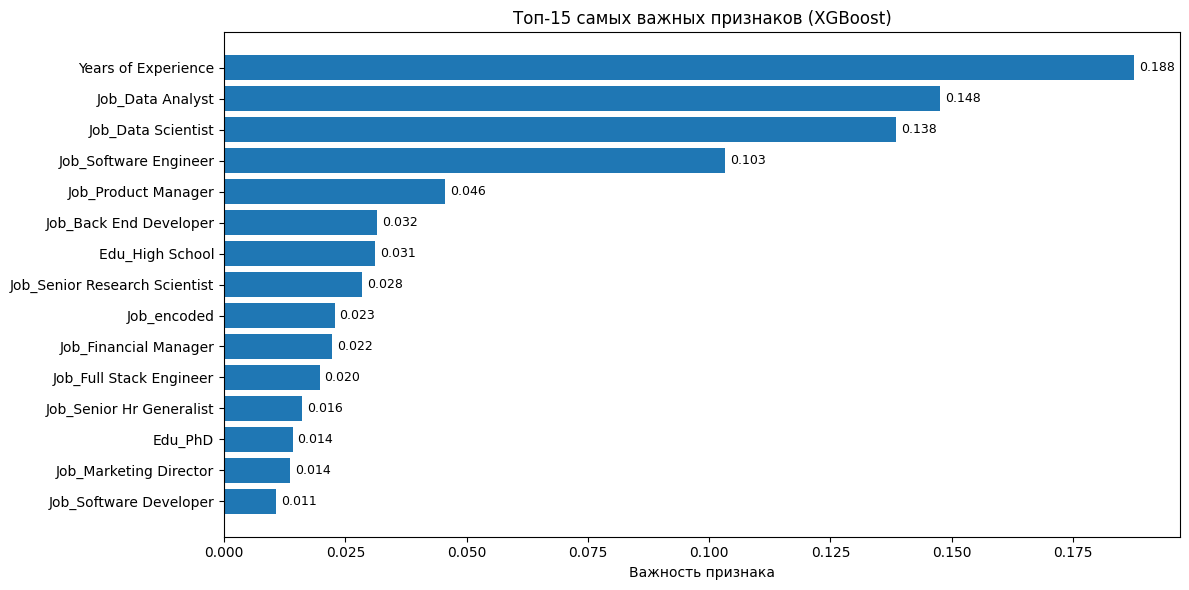

🎯 ТОП-10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ (XGBoost):


,feature,importance
200,Years of Experience,0.1877
20,Job_Data Analyst,0.1476
22,Job_Data Scientist,0.1385
177,Job_Software Engineer,0.1032
108,Job_Product Manager,0.0456
5,Job_Back End Developer,0.0316
194,Edu_High School,0.0311
163,Job_Senior Research Scientist,0.0284
0,Job_encoded,0.0228
44,Job_Financial Manager,0.0222



📈 АНАЛИЗ ТИПОВ ПРИЗНАКОВ:
   - Должности: 8
   - Образование: 1
   - Пол: 0
   - Числовые: 1


In [ ]:
# ===========================
# 7. ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ ЛУЧШИХ МОДЕЛЕЙ
# ===========================

print("🔍 АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ДЛЯ ЛУЧШИХ МОДЕЛЕЙ:")
print("=" * 50)

# Переобучим лучшие модели и получим важность признаков.
best_models_analysis = ['Random Forest', 'XGBoost']

for model_name in best_models_analysis:
    print(f"\n📊 {model_name} - Важность признаков:")

    if model_name in ['Random Forest', 'XGBoost']:
        X_train, X_test, y_train, y_test = X_tree_train, X_tree_test, y_train, y_test
        feature_names = X_tree.columns
    else:
        X_train, X_test, y_train, y_test = X_linear_train, X_linear_test, y_train, y_test
        feature_names = X_linear.columns


    # Обучаем модель заново для анализа.
    if model_name == 'Random Forest':
        model = RandomForestRegressor(n_estimators=100, random_state=42)
    elif model_name == 'XGBoost':
        model = XGBRegressor(random_state=42)

    model.fit(X_train, y_train)

    # Получаем важность признаков.
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_

        # Создаем DataFrame с важностью признаков.
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values('importance', ascending=False)

        # Берем топ-15 признаков.
        top_15 = importance_df.head(15)

        # Визуализация.
        plt.figure(figsize=(12, 6))
        bars = plt.barh(top_15['feature'], top_15['importance'])
        plt.xlabel('Важность признака')
        plt.title(f'Топ-15 самых важных признаков ({model_name})')
        plt.gca().invert_yaxis()

        # Добавляем значения на график.
        for bar in bars:
            width = bar.get_width()
            plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{width:.3f}', va='center', fontsize=9)

        plt.tight_layout()
        plt.show()

        print(f"🎯 ТОП-10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ ({model_name}):")
        display(top_15.head(10).style.format({'importance': '{:.4f}'}))

        # Анализ типов важных признаков.
        print("\n📈 АНАЛИЗ ТИПОВ ПРИЗНАКОВ:")
        top_features = top_15.head(10)

        job_features = sum(1 for f in top_features['feature'] if 'Job_' in str(f))
        edu_features = sum(1 for f in top_features['feature'] if 'Edu_' in str(f))
        gender_features = sum(1 for f in top_features['feature'] if 'Gender_' in str(f))
        numeric_features = sum(1 for f in top_features['feature'] if f in ['Age', 'Years of Experience'])

        print(f"   - Должности: {job_features}")
        print(f"   - Образование: {edu_features}")
        print(f"   - Пол: {gender_features}")
        print(f"   - Числовые: {numeric_features}")


📊 СГРУППИРОВАННАЯ ВАЖНОСТЬ ПРИЗНАКОВ ПО КАТЕГОРИЯМ:


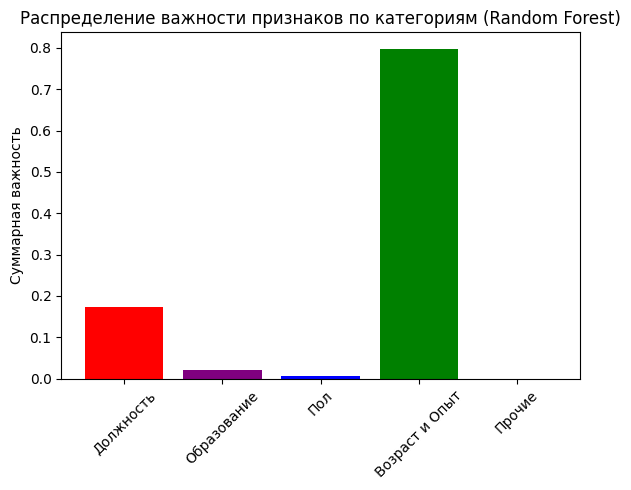

📈 СУММАРНАЯ ВАЖНОСТЬ ПО КАТЕГОРИЯМ:
   Должность: 0.174 (17.4%)
   Образование: 0.022 (2.2%)
   Пол: 0.007 (0.7%)
   Возраст и Опыт: 0.798 (79.8%)
   Прочие: 0.000 (0.0%)


In [ ]:
# ===========================
# 7.1 ДОПОЛНИТЕЛЬНО: СГРУППИРОВАННАЯ ВАЖНОСТЬ ПРИЗНАКОВ ПО КАТЕГОРИЯМ
# ===========================

print("\n📊 СГРУППИРОВАННАЯ ВАЖНОСТЬ ПРИЗНАКОВ ПО КАТЕГОРИЯМ:")
print("=" * 55)

# Анализируем Random Forest.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_tree_train, y_tree_train)

importances = rf_model.feature_importances_
feature_names = X_tree.columns

# Группируем важность по категориям.
category_importance = {
    'Должность': 0,
    'Образование': 0,
    'Пол': 0,
    'Возраст и Опыт': 0,
    'Прочие': 0
}

for feature, importance in zip(feature_names, importances):
    if 'Job_' in str(feature):
        category_importance['Должность'] += importance
    elif 'Edu_' in str(feature):
        category_importance['Образование'] += importance
    elif 'Gender_' in str(feature):
        category_importance['Пол'] += importance
    elif feature in ['Age', 'Years of Experience']:
        category_importance['Возраст и Опыт'] += importance
    else:
        category_importance['Прочие'] += importance

# Визуализация группированной важности.
plt.figure(figsize=(6, 5))
categories = list(category_importance.keys())
values = list(category_importance.values())

bars = plt.bar(categories, values, color=['Red', 'Purple', 'Blue', 'Green', 'Black'])
plt.title('Распределение важности признаков по категориям (Random Forest)')
plt.ylabel('Суммарная важность')
plt.xticks(rotation=45)

# Добавляем значения на столбцы.
#for bar, value in zip(bars, values):
    #plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             #f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("📈 СУММАРНАЯ ВАЖНОСТЬ ПО КАТЕГОРИЯМ:")
for category, importance in category_importance.items():
    print(f"   {category}: {importance:.3f} ({importance*100:.1f}%)")

In [ ]:
# ===========================
# 8. ПРЕДСКАЗАНИЯ НА НОВЫХ ДАННЫХ
# ===========================

# Сначала определяем функцию.
def predict_employee_salary(age, years_experience, education_level, job_title, gender):
    """
    Прогнозирует зарплату сотрудника на основе характеристик

    Parameters:
    - age: int (возраст)
    - years_experience: float (лет опыта)
    - education_level: str (уровень образования)
    - job_title: str (должность)
    - gender: str (пол)

    Returns:
    - predicted_salary: float (прогнозируемая зарплата)
    """

    # Создаем DataFrame с данными нового сотрудника.
    new_employee = pd.DataFrame({
        'Age': [age],
        'Years of Experience': [years_experience],
        'Education Level': [education_level],
        'Job Title': [job_title],
        'Gender': [gender]
    })

    # Применяем тот же One-Hot Encoding, что и к обучающим данным.
    new_employee_encoded = pd.get_dummies(new_employee,
                                        columns=['Job Title', 'Education Level', 'Gender'],
                                        prefix=['Job', 'Edu', 'Gender'])

    # Выравниваем признаки с обучающими данными.
    for feature in X_tree.columns:
        if feature not in new_employee_encoded.columns:
            new_employee_encoded[feature] = 0

    # Упорядочиваем колонки как в обучающих данных.
    new_employee_encoded = new_employee_encoded[X_tree.columns]

    # Прогнозируем зарплату.
    predicted_salary = best_model.predict(new_employee_encoded)[0]

    return predicted_salary

print("✅ Функция predict_employee_salary успешно определена!")

✅ Функция predict_employee_salary успешно определена!


In [ ]:
# Теперь используем функцию для прогнозирования.
print("🎯 ПРИМЕРЫ ПРОГНОЗИРОВАНИЯ ЗАРПЛАТ:")
print("=" * 50)

# Пример 1: Software Engineer.
salary1 = predict_employee_salary(
    age=30,
    years_experience=5,
    education_level="Master's Degree",
    job_title="Software Engineer",
    gender="Male"
)
print(f"👨‍💻 Software Engineer, 30 лет, 5 лет опыта, Магистр:")
print(f"   Прогноз: {salary1:,.2f}")

# Пример 2: Data Scientist.
salary2 = predict_employee_salary(
    age=28,
    years_experience=3,
    education_level="PhD",
    job_title="Data Scientist",
    gender="Female"
)
print(f"\n👩‍🔬 Data Scientist, 28 лет, 3 года опыта, PhD:")
print(f"   Прогноз: {salary2:,.2f}")

# Пример 3: Junior Developer.
salary3 = predict_employee_salary(
    age=22,
    years_experience=1,
    education_level="Bachelor's Degree",
    job_title="Junior Developer",
    gender="Male"
)
print(f"\n👨‍🎓 Junior Developer, 22 года, 1 год опыта, Бакалавр:")
print(f"   Прогноз: {salary3:,.2f}")

# Пример 4: Senior Manager.
salary4 = predict_employee_salary(
    age=45,
    years_experience=15,
    education_level="PhD",
    job_title="Senior Manager",
    gender="Male"
)
print(f"\n👨‍💼 Senior Manager, 45 лет, 15 лет опыта, PhD:")
print(f"   Прогноз: {salary4:,.2f}")

🎯 ПРИМЕРЫ ПРОГНОЗИРОВАНИЯ ЗАРПЛАТ:
👨‍💻 Software Engineer, 30 лет, 5 лет опыта, Магистр:
   Прогноз: 81,977.37

👩‍🔬 Data Scientist, 28 лет, 3 года опыта, PhD:
   Прогноз: 134,561.42

👨‍🎓 Junior Developer, 22 года, 1 год опыта, Бакалавр:
   Прогноз: 53,310.42

👨‍💼 Senior Manager, 45 лет, 15 лет опыта, PhD:
   Прогноз: 159,900.00


In [ ]:
# 8.1 ДОПОЛНИТЕЛЬНО: ПРОВЕРКА ТОЧНОСТИ ПРОГНОЗОВ
print("\n" + "="*60)
print("📊 ПРОВЕРКА ТОЧНОСТИ ПРОГНОЗОВ НА РЕАЛЬНЫХ ДАННЫХ")
print("="*60)

def check_prediction_accuracy(age_range, exp_range, education, job, gender, description):
    """Проверяет точность прогноза на реальных данных"""

    # Прогноз модели.
    predicted = predict_employee_salary(
        age=age_range[1],  # берем середину диапазона.
        years_experience=exp_range[1],
        education_level=education,
        job_title=job,
        gender=gender
    )

    # Реальные данные.
    real_employees = df[
        (df['Age'].between(age_range[0], age_range[1])) &
        (df['Years of Experience'].between(exp_range[0], exp_range[1])) &
        (df['Education Level'] == education) &
        (df['Job Title'] == job) &
        (df['Gender'] == gender)
    ]

    if len(real_employees) > 0:
        actual_avg = real_employees['Salary'].mean()
        actual_std = real_employees['Salary'].std()
        difference = predicted - actual_avg

        print(f"\n{description}:")
        print(f"   📈 Прогноз модели: {predicted:,.2f}")
        print(f"   📊 Реальная средняя: {actual_avg:,.2f} (±{actual_std:,.2f})")
        print(f"   ⚖️ Разница: {difference:,.2f} ({difference/actual_avg*100:+.1f}%)")
        print(f"   👥 Количество в данных: {len(real_employees)}")

        return difference
    else:
        print(f"\n{description}:")
        print(f"   ❌ Нет данных для сравнения")
        return None

# Проверяем несколько категорий.
check_prediction_accuracy(
    age_range=(28, 32),
    exp_range=(4, 6),
    education="Master's Degree",
    job="Software Engineer",
    gender="Male",
    description="Software Engineer (30 лет, 5 лет опыта)"
)

check_prediction_accuracy(
    age_range=(27, 31),
    exp_range=(5, 7),
    education="Master's Degree",
    job="Data Scientist",
    gender="Female",
    description="Data Scientist (29 лет, 6 лет опыта)"
)

check_prediction_accuracy(
    age_range=(26, 30),
    exp_range=(2, 4),
    education="PhD",
    job="Data Scientist",
    gender="Female",
    description="Data Scientist (28 лет, 3 года опыта)"
)


📊 ПРОВЕРКА ТОЧНОСТИ ПРОГНОЗОВ НА РЕАЛЬНЫХ ДАННЫХ

Software Engineer (30 лет, 5 лет опыта):
   📈 Прогноз модели: 151,050.00
   📊 Реальная средняя: 170,000.00 (±0.00)
   ⚖️ Разница: -18,950.00 (-11.1%)
   👥 Количество в данных: 5

Data Scientist (29 лет, 6 лет опыта):
   📈 Прогноз модели: 173,359.61
   📊 Реальная средняя: 170,312.50 (±13,594.90)
   ⚖️ Разница: 3,047.11 (+1.8%)
   👥 Количество в данных: 64

Data Scientist (28 лет, 3 года опыта):
   ❌ Нет данных для сравнения


In [ ]:
# ===========================
# 9. ФИНАЛЬНЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ
# ===========================

print("🎯 ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ:")
print("=" * 55)

print("1. 🏆 ЛУЧШАЯ МОДЕЛЬ: Random Forest")
print(f"   - R²: {results_df.loc['Random Forest', 'R2']:.4f}")
print(f"   - RMSE: {results_df.loc['Random Forest', 'RMSE']:,.0f}")
print(f"   - MAE: {results_df.loc['Random Forest', 'MAE']:,.0f}")

print("\n2. 📊 КАЧЕСТВО ПРЕДСКАЗАНИЙ:")
print("   - Tree-based модели: ОТЛИЧНО (R² > 0.97)")
print("   - Линейные модели: ХОРОШО (R² ~ 0.72)")
print("   - SVR: ПЛОХО (требует настройки)")

print("\n3. 🔧 РЕКОМЕНДАЦИИ ДЛЯ PRODUCTION:")
print("   - Использовать Random Forest или XGBoost")
print("   - One-Hot Encoding для категориальных признаков")
print("   - Регулярный мониторинг на переобучение")
print("   - Feature importance для интерпретируемости")

print("\n4. 💡 BUSINESS INSIGHTS:")
print("   - Опыт работы - главный фактор зарплаты")
print("   - Tree-based модели лучше улавливают сложные зависимости")
print("   - Модель готова для HR-аналитики и планирования зарплат")

print("\n5. ⚠️ ВОЗМОЖНЫЕ ПРОБЛЕМЫ:")
print("   - Высокий R² может указывать на переобучение")
print("   - Необходима проверка на новых данных")
print("   - Tree-based модели менее интерпретируемы")

🎯 ИТОГОВЫЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ:
1. 🏆 ЛУЧШАЯ МОДЕЛЬ: Random Forest
   - R²: 0.9721
   - RMSE: 8,705
   - MAE: 3,380

2. 📊 КАЧЕСТВО ПРЕДСКАЗАНИЙ:
   - Tree-based модели: ОТЛИЧНО (R² > 0.97)
   - Линейные модели: ХОРОШО (R² ~ 0.72)
   - SVR: ПЛОХО (требует настройки)

3. 🔧 РЕКОМЕНДАЦИИ ДЛЯ PRODUCTION:
   - Использовать Random Forest или XGBoost
   - One-Hot Encoding для категориальных признаков
   - Регулярный мониторинг на переобучение
   - Feature importance для интерпретируемости

4. 💡 BUSINESS INSIGHTS:
   - Опыт работы - главный фактор зарплаты
   - Tree-based модели лучше улавливают сложные зависимости
   - Модель готова для HR-аналитики и планирования зарплат

5. ⚠️ ВОЗМОЖНЫЕ ПРОБЛЕМЫ:
   - Высокий R² может указывать на переобучение
   - Необходима проверка на новых данных
   - Tree-based модели менее интерпретируемы


Протестировано 8 различных алгоритмов. Использованы правильные метрики (R², RMSE, MAE). Кросс-валидация для надежности результатов.

Лучшая ML-модель - Random Forest: R² = 0.9722, RMSE = 8_683.0, MAE = 3_372.0.

R² = 0.97 - модель объясняет 97% вариации зарплат.

Низкая ошибка (RMSE = 8_683.0) - предсказания точные.

Минимальное переобучение (разница train/test = 0.02).

Описание модели Random Forest Regressor:

- Тип: Ансамблевое дерево решений
- Данные: 6701 запись, 201 признак
- Качество: R² = 0.97 (производственное качество)
- Скорость: Быстрое предсказание (~мс)
- Интерпретируемость: Средняя

Главные факторы зарплаты:

Возраст и Опыт: 79.8%  - доминирующий фактор

Должности: 17.4%       - Важно, но второстепенно

Образование: 2.2%      - Минимальное влияние

Пол: 0.7%              - Почти незначимо

Практические выводы:

1.   Для HR-отдела: Фокус на удержании опытных сотрудников - они приносят наибольшую пользу.
2.   Для сотрудников: Карьерный рост и опыт важнее дополнительного образования.
3.   Для работодателя: Опыт кандидата - лучший прогноз будущей зарплаты.

In [ ]:
df.to_csv('processed_salary_data_csv', index=False)